In [79]:

## Importing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.impute import SimpleImputer

In [80]:
## Loading Data
fce = pd.read_csv("../datasets/farm_cat_eco.csv")

In [81]:
## Inspect data
fce.head()


,year,territory,lambs,rams,ewes,lamb_sheep_shorn,sheep_flock,sheep_purchased,cats_occurrence_total,cats_forest,...,eco_sector_authorities_stakeholders,eco_sector_environment,eco_sector_health,eco_type_control,eco_type_control_education,eco_type_control_medical_care,eco_type_control_prevention,eco_type_damage_loss,eco_type_eradication,eco_type_prevention
0,2002,All Australia,10658.0,662.0,26531.0,51883.0,47861.0,3300.0,197.0,77.0,...,825276.359414,0.0,0.0,825276.359414,0.0,0.0,0.0,0.0,0.0,0.0
1,2002,New South Wales,2624.0,131.0,5996.0,11360.0,10544.0,770.0,104.0,46.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2002,Northern Territory,0.0,0.0,0.0,0.0,0.0,0.0,34.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2002,Queensland,1421.0,103.0,5020.0,11123.0,9707.0,584.0,24.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2002,South Australia,2148.0,137.0,5372.0,8857.0,8938.0,692.0,18.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
fce.isna().sum()

year                                     0
territory                                0
lambs                                   25
rams                                    25
ewes                                    25
lamb_sheep_shorn                        11
sheep_flock                             11
sheep_purchased                         11
cats_occurrence_total                   32
cats_forest                             32
eco_cost_total                         146
eco_cost_cat_only                      146
eco_cost_cat_plus_other                146
eco_sector_agriculture                 146
eco_sector_authorities_stakeholders    146
eco_sector_environment                 146
eco_sector_health                      146
eco_type_control                       146
eco_type_control_education             146
eco_type_control_medical_care          146
eco_type_control_prevention            146
eco_type_damage_loss                   146
eco_type_eradication                   146
eco_type_pr

In [83]:
# Clean column names
fce.columns = fce.columns.str.strip()

# Keep only Australia
fce = fce[fce["territory"] == "All Australia"].copy()

fce = fce[[
    'year',
    'cats_occurrence_total',
    'sheep_flock',
    'territory',
    'eco_cost_total',
    'eco_type_control',
    'eco_type_control_education',
    'eco_type_control_medical_care',
    'eco_type_control_prevention',
    'eco_type_damage_loss',
    'eco_type_eradication',
    'eco_type_prevention'
]]

In [84]:
fce.isna().sum()

year                             0
cats_occurrence_total            0
sheep_flock                      0
territory                        0
eco_cost_total                   8
eco_type_control                 8
eco_type_control_education       8
eco_type_control_medical_care    8
eco_type_control_prevention      8
eco_type_damage_loss             8
eco_type_eradication             8
eco_type_prevention              8
dtype: int64

In [85]:
fce = fce.dropna(subset=[
    'cats_occurrence_total',
    'sheep_flock',
    'eco_type_damage_loss'
])

In [86]:
## Adding "all Australia"
aus = fce[fce["territory"] == "All Australia"]

# Type of cost categorization




In [87]:
## Type of costs diviation 
cost_types = [
    "eco_type_control",
    "eco_type_damage_loss",
    "eco_type_eradication",
    "eco_type_prevention"
]

cost_structure = aus[cost_types].sum()
cost_structure = cost_structure.round(0).astype(int)
cost_structure

eco_type_control         2282268
eco_type_damage_loss     7940169
eco_type_eradication    33836150
eco_type_prevention      1213341
dtype: int32

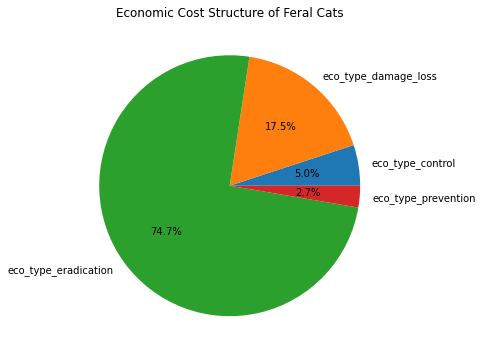

In [88]:
## Visualizing

cost_structure.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Economic Cost Structure of Feral Cats")
plt.ylabel("")
plt.show()

# Control Vs. Damage costs comparison


In [89]:
## Control Costs categorization
control_cost = (
    cost_structure["eco_type_control"]
    + cost_structure["eco_type_eradication"]
    + cost_structure["eco_type_prevention"]
)

In [90]:
## Damage Cost Categorization
damage_cost = cost_structure["eco_type_damage_loss"]

In [91]:
comparison = pd.Series({
    "Control spending": control_cost,
    "Damage losses": damage_cost
})

comparison

Control spending    37331759
Damage losses        7940169
dtype: int32

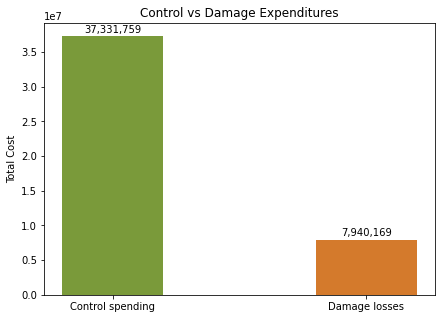

In [92]:
## Visualization of the control VS. damage stats
labels = comparison.index
values = comparison.values

x = np.arange(len(labels))

plt.figure(figsize=(7,5))

plt.bar(x, values, width=0.4, color=["#7a9a3a", "#d47a2c"])

plt.xticks(x, labels)
plt.ylabel("Total Cost")
plt.title("Control vs Damage Expenditures")

for i, v in enumerate(values):
    plt.text(i, v + 500000, f"{v:,.0f}", ha="center")

plt.show()

## Temporal Dynamics of Economic Cost

First, we aggrigate overall economics cost by year

In [93]:
## Costs by year depedning on the type of loss
cost_by_year = aus.groupby("year")[cost_types].sum()

cost_by_year = cost_by_year.applymap(lambda x: f"{x:,.0f}")
cost_by_year

,eco_type_control,eco_type_damage_loss,eco_type_eradication,eco_type_prevention
year,,,,
2002,"825,276",0,0,0
2004,"1,180,696",0,0,0
2006,"11,185",0,"3,139,774",0
2009,0,0,0,0
2010,"11,162",0,"29,227",0
2011,0,0,"111,794",0
2012,"126,802",0,"1,102",0
2013,"29,462",0,"28,708,160",0
2014,"2,023",0,0,"1,213,341"


### Cost dynamics by category

To compare how different cost categories evolve over time, we visualize each category in a separate subplot.  
All plots share the same scale to allow a direct comparison of expenditure levels across categories.

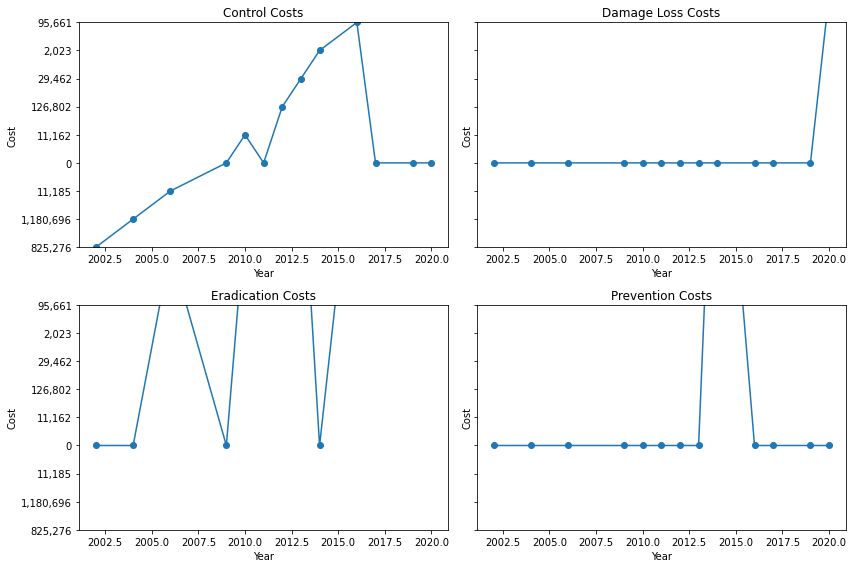

In [94]:

nice_names = {
    "eco_type_control": "Control Costs",
    "eco_type_damage_loss": "Damage Loss Costs",
    "eco_type_eradication": "Eradication Costs",
    "eco_type_prevention": "Prevention Costs"
}


max_val = cost_by_year.max().max()

fig, axes = plt.subplots(2, 2, figsize=(12,8), sharey=True)

axes = axes.flatten()

for i, col in enumerate(cost_types):
    axes[i].plot(cost_by_year.index, cost_by_year[col], marker="o")
    axes[i].set_title(nice_names[col])
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Cost")
    axes[i].set_ylim(0, max_val)  

plt.tight_layout()
plt.show()

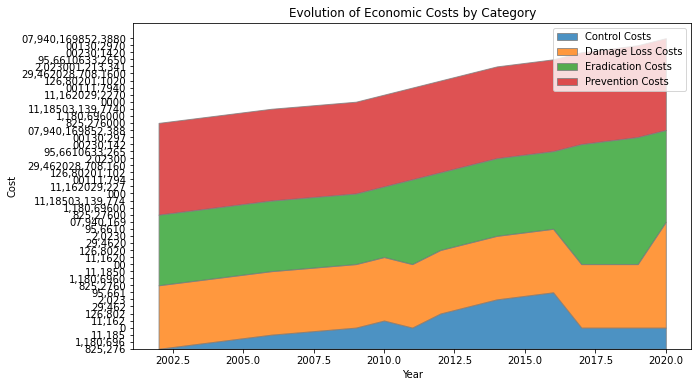

In [95]:
## All costs in one chart

plot_data = cost_by_year.rename(columns=nice_names)

plt.figure(figsize=(10,6))

plt.stackplot(
    plot_data.index,
    plot_data.T,
    labels=plot_data.columns,
    alpha=0.8,
    edgecolor="gray",
    linewidth=1
)

plt.title("Evolution of Economic Costs by Category")
plt.xlabel("Year")
plt.ylabel("Cost")
plt.legend()
plt.show()

### Total economic cost over time

Next, we calculate the total economic cost per year by summing all cost categories.  
This helps us observe how the overall economic impact of feral cats changes across years.

In [96]:
total_cost_year = cost_by_year.sum(axis=1)
total_cost_year

year
2002            825,276000
2004          1,180,696000
2006     11,18503,139,7740
2009                  0000
2010        11,162029,2270
2011            00111,7940
2012        126,80201,1020
2013    29,462028,708,1600
2014      2,023001,213,341
2016       95,6610633,2650
2017            00230,1420
2019            00130,2970
2020    07,940,169852,3880
dtype: object

### Visualizing total cost dynamics

We plot the evolution of total economic costs over time to identify trends, spikes, or periods of intensified management efforts.

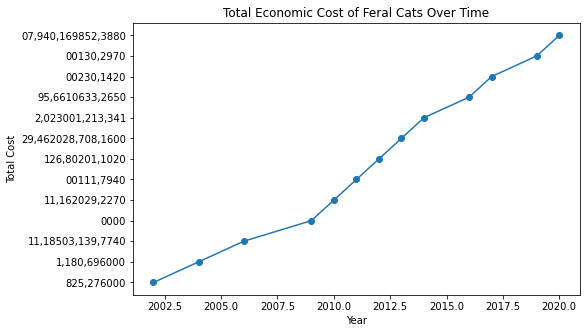

In [97]:

plt.figure(figsize=(8,5))

plt.plot(total_cost_year.index, total_cost_year.values, marker="o")

plt.title("Total Economic Cost of Feral Cats Over Time")
plt.xlabel("Year")
plt.ylabel("Total Cost")

plt.show()

## Violation testing

## Linearity

In [98]:
fce.columns = fce.columns.str.strip()

## convertation to numbers
cols = ['cats_occurrence_total', 'eco_cost_total', 'sheep_flock']

for col in cols:
    fce[col] = pd.to_numeric(fce[col], errors='coerce')

# all Australia
aus = fce[fce['territory'] == 'All Australia'].copy()

aus = aus.sort_values('year').dropna(
    subset=['cats_occurrence_total', 'eco_cost_total']
)

## X и y
X = aus['cats_occurrence_total'].values.reshape(-1, 1)
y = aus['eco_cost_total'].values

##  Linear Regression
lin = LinearRegression().fit(X, y)
y_pred_lin = lin.predict(X)
residuals = y - y_pred_lin

## Polynomial
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

pol = LinearRegression().fit(X_poly, y)
y_pred_poly = pol.predict(X_poly)

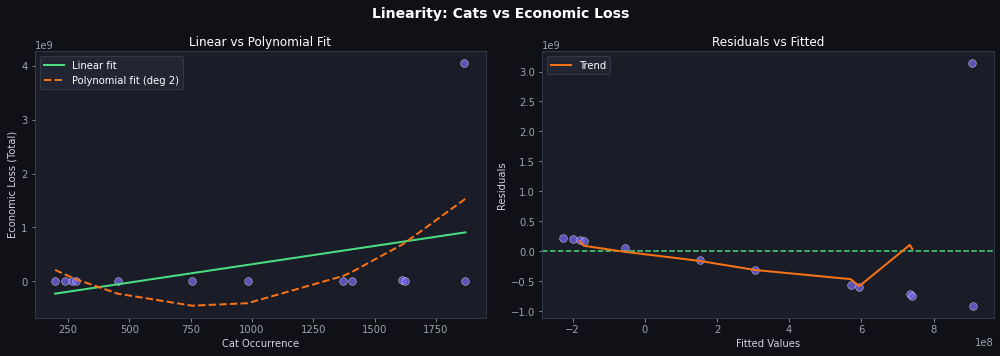

In [99]:
DARK, CARD = '#0f1117', '#1a1d27'
A1, A2, A3 = '#7c6af7', '#4ade80', '#f97316'

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
fig.suptitle('Linearity: Cats vs Economic Loss', fontsize=14, color='white', fontweight='bold')

for ax in axes:
    ax.set_facecolor(CARD)
    ax.tick_params(colors='#9ca3af')
    ax.xaxis.label.set_color('#d1d5db')
    ax.yaxis.label.set_color('#d1d5db')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

## Scatter + fits
ax = axes[0]
ax.scatter(X, y, color=A1, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

sort_idx = X.flatten().argsort()
ax.plot(X[sort_idx], y_pred_lin[sort_idx], color=A2, linewidth=2, label='Linear fit')
ax.plot(X[sort_idx], y_pred_poly[sort_idx], color=A3, linewidth=2,
        linestyle='--', label='Polynomial fit (deg 2)')

ax.set_xlabel('Cat Occurrence')
ax.set_ylabel('Economic Loss (Total)')
ax.set_title('Linear vs Polynomial Fit')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

## Residuals
ax = axes[1]
ax.scatter(y_pred_lin, residuals, color=A1, alpha=0.7, s=60,
           edgecolors='white', linewidth=0.5)

ax.axhline(0, color=A2, linewidth=1.5, linestyle='--')

sort_idx2 = y_pred_lin.argsort()
ax.plot(np.sort(y_pred_lin),
        pd.Series(residuals[sort_idx2]).rolling(5, center=True).mean(),
        color=A3, linewidth=2, label='Trend')

ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

plt.tight_layout()
plt.show()

## R^2 results:

In [100]:


print(f"Linear R²:     {lin.score(X, y):.4f}")
print(f"Polynomial R²: {pol.score(X_poly, y):.4f}")

Linear R²:     0.1595
Polynomial R²: 0.3232


cat occurrence alone is a poor predictor of economic losses...

## Autocorrelation

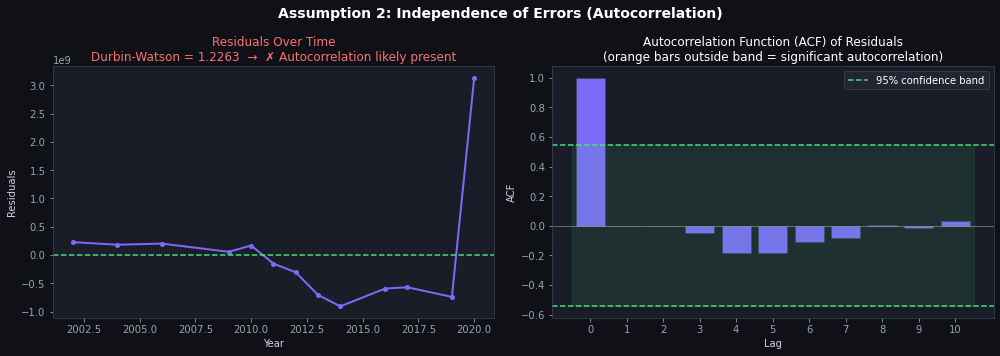

Durbin-Watson: 1.2263
Interpretation: ~2 = no autocorrelation | <1.5 = positive | >2.5 = negative


In [101]:
# делаем нужные колонки числовыми
cols = ['year', 'cats_occurrence_total', 'eco_cost_total']

for col in cols:
    fce[col] = pd.to_numeric(fce[col], errors='coerce')

# берем только All Australia
aus = fce[fce['territory'] == 'All Australia'].copy()

# сортируем по году и убираем пропуски
aus = aus.sort_values('year').dropna(subset=['cats_occurrence_total', 'eco_cost_total'])

# X и y
X = aus['cats_occurrence_total'].values.reshape(-1, 1)
y = aus['eco_cost_total'].values

# линейная регрессия и остатки
lin = LinearRegression().fit(X, y)
y_pred = lin.predict(X)
residuals = y - y_pred

# Durbin-Watson statistic
dw = np.sum(np.diff(residuals) ** 2) / np.sum(residuals ** 2)

# ACF function
def acf(x, nlags=10):
    n = len(x)
    xd = x - x.mean()
    var = np.dot(xd, xd) / n
    return [
        np.dot(xd[:n-lag], xd[lag:]) / n / var if lag < n else 0
        for lag in range(nlags + 1)
    ]

lags_range = min(10, len(residuals) - 1)
acf_vals = np.array(acf(residuals, nlags=lags_range))
conf = 1.96 / np.sqrt(len(residuals))

# colors
DARK, CARD = '#0f1117', '#1a1d27'
A1, A2, A3 = '#7c6af7', '#4ade80', '#f97316'

# plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
fig.suptitle('Assumption 2: Independence of Errors (Autocorrelation)',
             fontsize=14, color='white', fontweight='bold')

for ax in axes:
    ax.set_facecolor(CARD)
    ax.tick_params(colors='#9ca3af')
    ax.xaxis.label.set_color('#d1d5db')
    ax.yaxis.label.set_color('#d1d5db')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

# residuals over time
ax = axes[0]
ax.plot(aus['year'].values, residuals, color=A1, linewidth=2, marker='o', markersize=4)
ax.axhline(0, color=A2, linewidth=1.5, linestyle='--')

verdict = "✓ No strong autocorrelation" if 1.5 < dw < 2.5 else "✗ Autocorrelation likely present"
v_color = '#4ade80' if 1.5 < dw < 2.5 else '#f87171'

ax.set_title(f'Residuals Over Time\nDurbin-Watson = {dw:.4f}  →  {verdict}')
ax.title.set_color(v_color)
ax.set_xlabel('Year')
ax.set_ylabel('Residuals')

# ACF plot
ax = axes[1]
lags = np.arange(lags_range + 1)
bar_colors = [A3 if abs(v) > conf and i > 0 else A1 for i, v in enumerate(acf_vals)]

ax.bar(lags, acf_vals, color=bar_colors, edgecolor='#374151', linewidth=0.5)
ax.axhline(conf, color=A2, linewidth=1.5, linestyle='--', label='95% confidence band')
ax.axhline(-conf, color=A2, linewidth=1.5, linestyle='--')
ax.fill_between([-0.5, lags_range + 0.5], -conf, conf, alpha=0.1, color=A2)
ax.axhline(0, color='white', linewidth=0.8, alpha=0.4)

ax.set_xticks(lags)
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')
ax.set_title('Autocorrelation Function (ACF) of Residuals\n'
             '(orange bars outside band = significant autocorrelation)')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

plt.tight_layout()
plt.show()

print(f"Durbin-Watson: {dw:.4f}")
print("Interpretation: ~2 = no autocorrelation | <1.5 = positive | >2.5 = negative")

The independence assumption was tested using the Durbin–Watson statistic and the autocorrelation function (ACF) of residuals. The Durbin–Watson value of 1.23 indicates positive autocorrelation, suggesting that model errors are correlated across time rather than random. This is further supported by the ACF plot, which shows significant correlation at lag 1. These results imply that the model is misspecified and fails to capture important time dynamics, indicating that economic losses exhibit persistence and are not fully explained by cat occurrence alone.

## Homoscodescity 

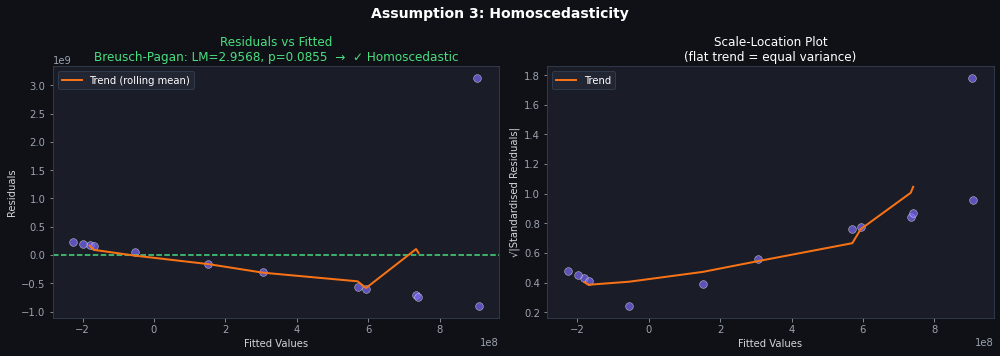

Breusch-Pagan LM: 2.9568, p=0.0855
If p < 0.05: heteroscedasticity present (violation).


In [102]:

fce.columns = fce.columns.str.strip()

cols = ['year', 'cats_occurrence_total', 'eco_cost_total']
for col in cols:
    fce[col] = pd.to_numeric(fce[col], errors='coerce')

aus = fce[fce['territory'] == 'All Australia'].copy()
aus = aus.sort_values('year').dropna(subset=['cats_occurrence_total', 'eco_cost_total'])

X = aus['cats_occurrence_total'].values.reshape(-1, 1)
y = aus['eco_cost_total'].values

lin = LinearRegression().fit(X, y)
y_pred = lin.predict(X)
residuals = y - y_pred

# Breusch-Pagan test (manual version)
resid_sq = residuals ** 2
X_bp = np.column_stack([np.ones(len(X)), X.flatten()])
beta = np.linalg.lstsq(X_bp, resid_sq, rcond=None)[0]
resid_sq_pred = X_bp @ beta

ss_res = np.sum((resid_sq - resid_sq_pred) ** 2)
ss_tot = np.sum((resid_sq - resid_sq.mean()) ** 2)
r2_bp = 1 - ss_res / ss_tot

n = len(y)
bp_lm = n * r2_bp
bp_p = 1 - stats.chi2.cdf(bp_lm, df=1)

DARK, CARD = '#0f1117', '#1a1d27'
A1, A2, A3 = '#7c6af7', '#4ade80', '#f97316'

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
fig.suptitle('Assumption 3: Homoscedasticity', fontsize=14,
             color='white', fontweight='bold')

for ax in axes:
    ax.set_facecolor(CARD)
    ax.tick_params(colors='#9ca3af')
    ax.xaxis.label.set_color('#d1d5db')
    ax.yaxis.label.set_color('#d1d5db')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

# Residuals vs fitted
ax = axes[0]
ax.scatter(y_pred, residuals, color=A1, alpha=0.7, s=60,
           edgecolors='white', linewidth=0.5)
ax.axhline(0, color=A2, linewidth=1.5, linestyle='--')

sort_idx = y_pred.argsort()
ax.plot(np.sort(y_pred),
        pd.Series(residuals[sort_idx]).rolling(5, center=True).mean(),
        color=A3, linewidth=2, label='Trend (rolling mean)')

verdict = "✓ Homoscedastic" if bp_p > 0.05 else "✗ Heteroscedastic"
v_color = '#4ade80' if bp_p > 0.05 else '#f87171'

ax.set_title(f'Residuals vs Fitted\nBreusch-Pagan: LM={bp_lm:.4f}, p={bp_p:.4f}  →  {verdict}')
ax.title.set_color(v_color)
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

# Scale-location plot
ax = axes[1]
std_resid = residuals / residuals.std()
ax.scatter(y_pred, np.sqrt(np.abs(std_resid)), color=A1, alpha=0.7,
           s=60, edgecolors='white', linewidth=0.5)
ax.plot(np.sort(y_pred),
        pd.Series(np.sqrt(np.abs(std_resid))[sort_idx]).rolling(5, center=True).mean(),
        color=A3, linewidth=2, label='Trend')

ax.set_xlabel('Fitted Values')
ax.set_ylabel('√|Standardised Residuals|')
ax.set_title('Scale-Location Plot\n(flat trend = equal variance)')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

plt.tight_layout()
plt.show()

print(f"Breusch-Pagan LM: {bp_lm:.4f}, p={bp_p:.4f}")
print("If p < 0.05: heteroscedasticity present (violation).")

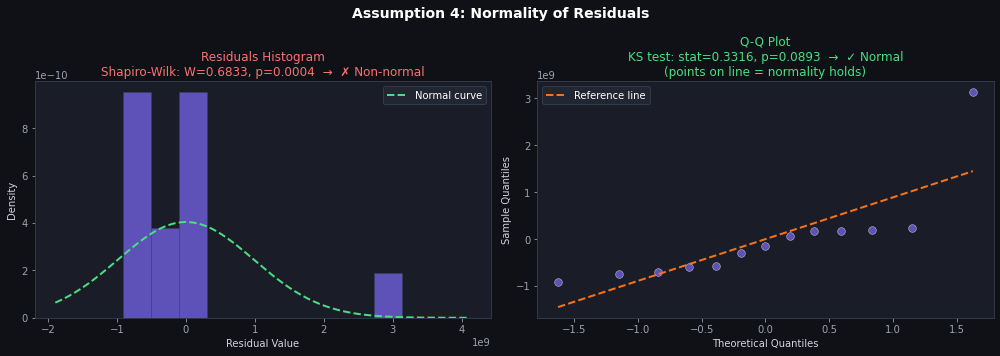

Shapiro-Wilk: W=0.6833, p=0.0004
KS test:      stat=0.3316, p=0.0893
If p < 0.05: residuals are not normally distributed (violation).


In [103]:
fce.columns = fce.columns.str.strip()

cols = ['year', 'cats_occurrence_total', 'eco_cost_total']
for col in cols:
    fce[col] = pd.to_numeric(fce[col], errors='coerce')

aus = fce[fce['territory'] == 'All Australia'].copy()
aus = aus.sort_values('year').dropna(subset=['cats_occurrence_total', 'eco_cost_total'])

X = aus['cats_occurrence_total'].values.reshape(-1, 1)
y = aus['eco_cost_total'].values

lin = LinearRegression().fit(X, y)
y_pred = lin.predict(X)
residuals = y - y_pred

sw_stat, sw_p = stats.shapiro(residuals)
ks_stat, ks_p = stats.kstest(
    residuals,
    'norm',
    args=(residuals.mean(), residuals.std())
)

DARK, CARD = '#0f1117', '#1a1d27'
A1, A2, A3 = '#7c6af7', '#4ade80', '#f97316'

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
fig.suptitle('Assumption 4: Normality of Residuals', fontsize=14,
             color='white', fontweight='bold')

for ax in axes:
    ax.set_facecolor(CARD)
    ax.tick_params(colors='#9ca3af')
    ax.xaxis.label.set_color('#d1d5db')
    ax.yaxis.label.set_color('#d1d5db')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

# Histogram
ax = axes[0]
ax.hist(residuals, bins=10, density=True, color=A1, alpha=0.7,
        edgecolor='#374151', linewidth=0.5)

x_line = np.linspace(
    residuals.min() - residuals.std(),
    residuals.max() + residuals.std(),
    200
)

ax.plot(
    x_line,
    stats.norm.pdf(x_line, residuals.mean(), residuals.std()),
    color=A2, linewidth=2, linestyle='--', label='Normal curve'
)

sw_verdict = "✓ Normal" if sw_p > 0.05 else "✗ Non-normal"
sw_color = '#4ade80' if sw_p > 0.05 else '#f87171'

ax.set_title(f'Residuals Histogram\nShapiro-Wilk: W={sw_stat:.4f}, p={sw_p:.4f}  →  {sw_verdict}')
ax.title.set_color(sw_color)
ax.set_xlabel('Residual Value')
ax.set_ylabel('Density')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

# Q-Q plot
ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')

ax.scatter(osm, osr, color=A1, alpha=0.7, s=60,
           edgecolors='white', linewidth=0.5)
ax.plot(osm, slope * np.array(osm) + intercept, color=A3,
        linewidth=2, linestyle='--', label='Reference line')

ks_verdict = "✓ Normal" if ks_p > 0.05 else "✗ Non-normal"
ks_color = '#4ade80' if ks_p > 0.05 else '#f87171'

ax.set_title(
    f'Q-Q Plot\nKS test: stat={ks_stat:.4f}, p={ks_p:.4f}  →  {ks_verdict}\n'
    f'(points on line = normality holds)'
)
ax.title.set_color(ks_color)
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

plt.tight_layout()
plt.show()

print(f"Shapiro-Wilk: W={sw_stat:.4f}, p={sw_p:.4f}")
print(f"KS test:      stat={ks_stat:.4f}, p={ks_p:.4f}")
print("If p < 0.05: residuals are not normally distributed (violation).")

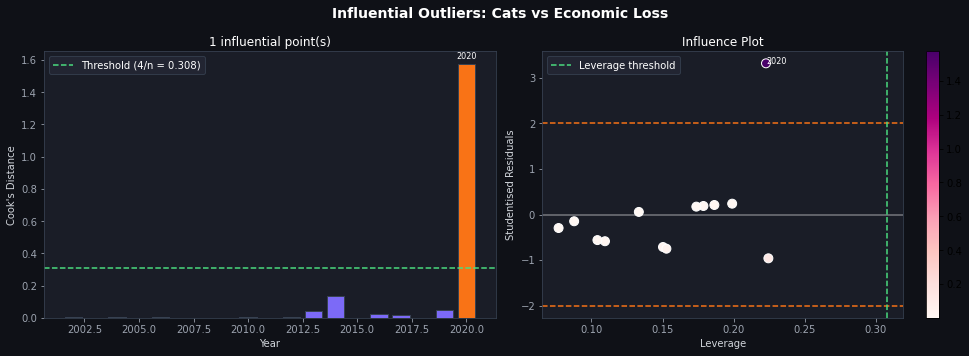


Cook's Distance threshold: 0.3077
Influential years: [2020]


In [104]:

# --- DATA ---
fce.columns = fce.columns.str.strip()

cols = ['year', 'cats_occurrence_total', 'eco_cost_total']
for col in cols:
    fce[col] = pd.to_numeric(fce[col], errors='coerce')

aus = fce[fce['territory'] == 'All Australia'].copy()
aus = aus.sort_values('year').dropna(subset=['cats_occurrence_total', 'eco_cost_total'])

X_raw = aus['cats_occurrence_total'].values
y = aus['eco_cost_total'].values
years = aus['year'].values
n = len(y)

# --- REGRESSION ---
X_mat = np.column_stack([np.ones(n), X_raw])

beta = np.linalg.lstsq(X_mat, y, rcond=None)[0]
y_pred = X_mat @ beta
residuals = y - y_pred

# --- LEVERAGE ---
H = X_mat @ np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T
leverage = np.diag(H)

# --- STANDARDIZED RESIDUALS ---
mse = np.sum(residuals ** 2) / (n - 2)
std_resid = residuals / np.sqrt(mse * (1 - leverage))

# --- COOK'S DISTANCE ---
k = 2
cooks_d = (std_resid ** 2 / k) * (leverage / (1 - leverage))

threshold = 4 / n

# --- STYLE ---
DARK, CARD = '#0f1117', '#1a1d27'
A1, A2, A3 = '#7c6af7', '#4ade80', '#f97316'

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
fig.suptitle("Influential Outliers: Cats vs Economic Loss",
             fontsize=14, color='white', fontweight='bold')

for ax in axes:
    ax.set_facecolor(CARD)
    ax.tick_params(colors='#9ca3af')
    ax.xaxis.label.set_color('#d1d5db')
    ax.yaxis.label.set_color('#d1d5db')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

# --- Cook's Distance ---
ax = axes[0]
colors = [A3 if d > threshold else A1 for d in cooks_d]

ax.bar(years, cooks_d, color=colors, edgecolor='#374151')
ax.axhline(threshold, color=A2, linestyle='--',
           label=f'Threshold (4/n = {threshold:.3f})')

for yr, d in zip(years, cooks_d):
    if d > threshold:
        ax.annotate(str(yr), (yr, d), xytext=(0, 5),
                    textcoords='offset points', ha='center', color='white', fontsize=8)

n_inf = sum(d > threshold for d in cooks_d)

ax.set_xlabel('Year')
ax.set_ylabel("Cook's Distance")
ax.set_title(f"{n_inf} influential point(s)")
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

# --- Leverage vs Residuals ---
ax = axes[1]

sc = ax.scatter(leverage, std_resid, c=cooks_d, cmap='RdPu',
                s=80, edgecolors='white')

ax.axhline(0, color='white', alpha=0.4)
ax.axhline(2, color=A3, linestyle='--')
ax.axhline(-2, color=A3, linestyle='--')

lev_thresh = 2 * k / n
ax.axvline(lev_thresh, color=A2, linestyle='--',
           label=f'Leverage threshold')

for lev, res, yr in zip(leverage, std_resid, years):
    if abs(res) > 2 or lev > lev_thresh:
        ax.annotate(str(yr), (lev, res), fontsize=8, color='white')

cb = plt.colorbar(sc, ax=ax)
cb.ax.yaxis.label.set_color('white')

ax.set_xlabel('Leverage')
ax.set_ylabel('Studentised Residuals')
ax.set_title('Influence Plot')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

plt.tight_layout()
plt.show()

print(f"\nCook's Distance threshold: {threshold:.4f}")
print("Influential years:",
      [years[i] for i, d in enumerate(cooks_d) if d > threshold])

Cook’s distance analysis identified the year 2020 as a highly influential observation. This suggests that the estimated relationship between cat occurrence and economic losses is disproportionately driven by a single extreme event. Removing this observation may significantly alter the model results, indicating that the relationship is not stable over time

In [105]:
aus_no_outlier = aus[aus['year'] != 2020]

X = aus_no_outlier[['cats_occurrence_total']]
y = aus_no_outlier['eco_cost_total']

model = LinearRegression().fit(X, y)

print(model.coef_, model.score(X, y))

[3849.61656486] 0.09038434530743511



After removing the influential observation (2020), the explanatory power of the model decreases further (R² ≈ 0.09), indicating that the relationship between cat occurrence and economic losses is weak and largely driven by extreme events rather than a stable underlying pattern

In [106]:
df_reg = fce[["eco_cost_total", "cats_occurrence_total", "year", "territory"]].copy()

numeric_cols = ["eco_cost_total", "cats_occurrence_total", "year"]
categorical_cols = ["territory"]

imputer = SimpleImputer(strategy="mean")
df_numeric_imputed = pd.DataFrame(
    imputer.fit_transform(df_reg[numeric_cols]),
    columns=numeric_cols
)

df_numeric_imputed["territory"] = df_reg["territory"].values

df_encoded = pd.get_dummies(
    df_numeric_imputed,
    columns=["territory"],
    drop_first=True
)

X = df_encoded.drop(columns=["eco_cost_total"])
y = df_encoded["eco_cost_total"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:,.2f}")

R²   : 0.1977
RMSE : 964,273,433.90


In [107]:
aus = fce[fce['territory'] == 'All Australia'].copy()
aus = aus.sort_values('year').reset_index(drop=True)

aus = aus[['year', 'cats_occurrence_total', 'eco_cost_total']].dropna()

lags = range(0, 6)
lag_corrs = []

for lag in lags:
    aus[f'cats_lag{lag}'] = aus['cats_occurrence_total'].shift(lag)
    tmp = aus.dropna(subset=[f'cats_lag{lag}', 'eco_cost_total'])
    
    if len(tmp) > 5:
        r, p = stats.pearsonr(tmp[f'cats_lag{lag}'], tmp['eco_cost_total'])
        lag_corrs.append({'lag': lag, 'r': r, 'p': p})

lag_df = pd.DataFrame(lag_corrs)

print(lag_df)

   lag         r         p
0    0  0.399313  0.176464
1    1  0.349713  0.265147
2    2  0.274002  0.414880
3    3  0.333222  0.346765
4    4  0.674033  0.046491
5    5  0.824937  0.011713


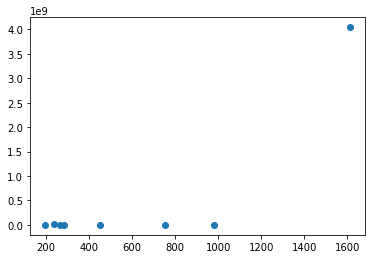

In [108]:
plt.scatter(tmp['cats_lag5'], tmp['eco_cost_total'])

Lagged correlation analysis suggests that the relationship between cat occurrence and economic losses is not immediate, but may materialize with a delay of approximately 4–5 years.

Although higher correlations are observed at longer lags, visual inspection reveals that these results are largely driven by a single extreme observation. Therefore, the apparent lagged relationship should be interpreted with caution and does not provide robust evidence of a systematic delayed effect."

In [109]:
Q1 = tmp['eco_cost_total'].quantile(0.25)
Q3 = tmp['eco_cost_total'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

tmp_no_outlier = tmp[
    (tmp['eco_cost_total'] >= lower) &
    (tmp['eco_cost_total'] <= upper)
]

r_clean, p_clean = stats.pearsonr(
    tmp_no_outlier['cats_lag5'],
    tmp_no_outlier['eco_cost_total']
)

print(f"Cleaned correlation: r = {r_clean:.3f}, p = {p_clean:.4f}")

Cleaned correlation: r = -0.255, p = 0.6252


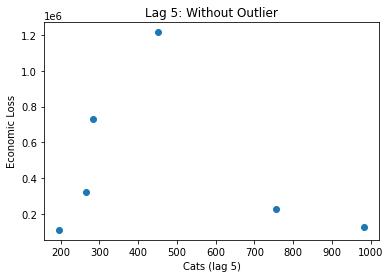

In [110]:
plt.scatter(
    tmp_no_outlier['cats_lag5'],
    tmp_no_outlier['eco_cost_total']
)
plt.title("Lag 5: Without Outlier")
plt.xlabel("Cats (lag 5)")
plt.ylabel("Economic Loss")
plt.show()

In [111]:
print("With outlier:", tmp_no_outlier)
print("Without outlier:", lag_df)

With outlier:     year  cats_occurrence_total  eco_cost_total  cats_lag0  cats_lag1  \
5   2011                  755.0    1.117943e+05      755.0      284.0   
6   2012                  982.0    3.213542e+05      982.0      755.0   
8   2014                 1870.0    1.215364e+06     1870.0     1612.0   
9   2016                 1406.0    7.289260e+05     1406.0     1870.0   
10  2017                 1371.0    2.301423e+05     1371.0     1406.0   
11  2019                 1622.0    1.302974e+05     1622.0     1371.0   

    cats_lag2  cats_lag3  cats_lag4  cats_lag5  
5       452.0      239.0      266.0      197.0  
6       284.0      452.0      239.0      266.0  
8       982.0      755.0      284.0      452.0  
9      1612.0      982.0      755.0      284.0  
10     1870.0     1612.0      982.0      755.0  
11     1406.0     1870.0     1612.0      982.0  
Without outlier:    lag         r         p
0    0  0.399313  0.176464
1    1  0.349713  0.265147
2    2  0.274002  0.414880
3    3

<AxesSubplot:xlabel='cats_occurrence_total', ylabel='eco_type_damage_loss'>

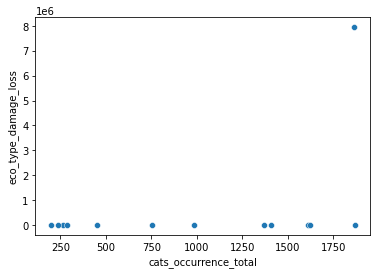

In [112]:
sns.scatterplot(
    x='cats_occurrence_total',
    y='eco_type_damage_loss',
    data=fce
)

In [113]:
tmp = fce[fce['territory'] == 'All Australia'][['year', 'cats_occurrence_total', 'eco_type_damage_loss']].copy()
tmp = tmp.sort_values('year')
tmp['cats_lag1'] = tmp['cats_occurrence_total'].shift(1)
tmp = tmp.dropna(subset=['cats_lag1', 'eco_type_damage_loss'])

r, p = stats.pearsonr(tmp['cats_lag1'], tmp['eco_type_damage_loss'])
print(f"r = {r:.3f}, p = {p:.4f}")

r = 0.350, p = 0.2653
